In [44]:
import nugget  # Main NUGGET package for neutrino detector optimization
import torch
import numpy as np
import matplotlib.pyplot as plt
import importlib
# import lognorm from matplotlib
from matplotlib import cm
Lognorm = cm.colors.LogNorm

In [3]:
importlib.reload(nugget.losses.fisher_info)  # Reload NUGGET package to ensure latest changes are used
device='cuda:2'
center = [0,0,0]
radius = 600
height = 1000
lightsabre_surrogate = nugget.surrogates.LightSabre.LightSabre(device=device, use_poisson=False, domain_size=1600, particle_mode = 'track')
light_yield_surrogate = lightsabre_surrogate.light_yield_surrogate_batched
signal_sampler = nugget.samplers.cyl_sampler.CylinderSampler(
                                                    device=None, 
                                                    event_type='signal', 
                                                    domain_size=1600, 
                                                    E_min=1e2, 
                                                    E_max=1e8, 
                                                    find_exact_intersection=True,
                                                    random_position_along_ray=False,  
                                                    energy_dist='log_uniform',
                                                    cylinder_center=center,
                                                    cylinder_radius=radius,
                                                    cylinder_height=height,
                                                    uniform_zenith_sampling=True,
                                                    cos_range=torch.tensor([0,1]),
                                                    # point_towards_center=True,
                                                    # cos_range=torch.tensor((np.cos(np.radians(155)),np.cos(np.radians(180))))
                                                    )
angular_resolution_loss = nugget.losses.fisher_info.WeightedResolutionLoss(
        device=device,
        resolution_type='angular',
        fisher_info_params=['energy', 'direction']
    )
energy_resolution_loss = nugget.losses.fisher_info.WeightedResolutionLoss(
    device=device,
    resolution_type='energy',
    fisher_info_params=['energy', 'direction']
)

In [21]:
num_events = 40000
angular_loss_dicts = {}
energy_loss_dicts = {}
spacing_min = 25
spacing_max = 150
spacing_count = 20

for energy in [2,3,4,5,6]:
    print(f"Running fisher info calculations for energy range: 10^{energy} GeV to 10^{energy+1 if energy < 6 else energy+2} GeV")
    signal_sampler = nugget.samplers.cyl_sampler.CylinderSampler(
                                                        device=None, 
                                                        event_type='signal', 
                                                        domain_size=1600, 
                                                        E_min=10**energy, 
                                                        E_max=10**(energy+1) if energy < 6 else 10**(energy+2), 
                                                        find_exact_intersection=True,
                                                        random_position_along_ray=False,  
                                                        energy_dist='log_uniform',
                                                        cylinder_center=center,
                                                        cylinder_radius=radius,
                                                        cylinder_height=height,
                                                        uniform_zenith_sampling=True,
                                                        cos_range=torch.tensor([0,1]),
                                                        # point_towards_center=True,
                                                        # cos_range=torch.tensor((np.cos(np.radians(155)),np.cos(np.radians(180))))
                                                        )
    if energy < 6:
        angular_loss_dicts[f'{energy}-{energy+1}'] = []
        energy_loss_dicts[f'{energy}-{energy+1}'] = []
    else:
        angular_loss_dicts[f'{energy}-{energy+2}'] = []
        energy_loss_dicts[f'{energy}-{energy+2}'] = []
    for string_spacing in np.logspace(np.log10(spacing_min), np.log10(spacing_max), spacing_count):
        print(f"Running fisher info calculations for string spacing: {string_spacing}m")
        geometry = nugget.geometries.SpaceString.SpaceString(
                device=device,
                hex_type='hexagonal',
                domain_size=2500,
                dim=3,
                n_strings=61,
                points_per_string=20,
                starting_spacing=string_spacing,
                starting_z_spacing=50
            )
        geom_dict = geometry.initialize_points()
        
        signal_events = signal_sampler.sample_events(num_events=num_events)
        loss_params = {
                    'signal_event_params': signal_events,
                    'signal_surrogate_func': light_yield_surrogate,
                    'llr_net': None,
                    'llr_iterations': 1,
                    'skip_zero_response': True,
                    'verbose': True,
                    'jacrev_chunk_size': 50000,
                    'point_chunk_size': 22000,
                    'grad_chunk_size': 7,
                    'llr_autodiff_mode': 'jvp',
                    'use_rich_features': True,
                    'use_patd': False,
                    'use_patd_quadrature': False,
                    't_offset_ns': 0,
                    't_max_ns': 5000,
                    'zero_response_threshold': 0.001,
                    'use_charge_quadrature': False,
                    'charge_center_on_llr_peak': False,
                    'adaptive_grid_retry': True,
                    'adaptive_t_max_floor_ns': 10,
                    'uninformative_fisher_value': 1e-6,
                    'precomputed_fisher_per_string_per_event': None,
                    'recompute_bad_points': False,
                    'empty_cache_after_event': True,
                    'events_per_batch': 100000,
                    }
        ang_loss_dict = angular_resolution_loss(
                    geom_dict=geom_dict,
                    **loss_params
                    )
        energy_loss_dict = energy_resolution_loss(
                    geom_dict=geom_dict,
                    **loss_params
                    )
        for key in ang_loss_dict:
            if isinstance(ang_loss_dict[key], torch.Tensor):
                ang_loss_dict[key] = ang_loss_dict[key].detach().cpu()
        for key in energy_loss_dict:
            if isinstance(energy_loss_dict[key], torch.Tensor):
                energy_loss_dict[key] = energy_loss_dict[key].detach().cpu()
        if energy < 6:
            angular_loss_dicts[f'{energy}-{energy+1}'].append(ang_loss_dict)
            energy_loss_dicts[f'{energy}-{energy+1}'].append(energy_loss_dict)
        else:
            angular_loss_dicts[f'{energy}-{energy+2}'].append(ang_loss_dict)
            energy_loss_dicts[f'{energy}-{energy+2}'].append(energy_loss_dict)

#     angular_foms.append(1/ang_loss_dict['angular_resolution_loss'])
#     mean_energies.append(torch.median(energy_loss_dict['resolution_per_event']))
#     print(f"String spacing: {string_spacing}m, Angular FOM: {angular_foms[-1]}, Median Energy Resolution: {mean_energies[-1]}")
# angular_foms = torch.stack(angular_foms).squeeze().cpu().numpy()
# mean_energies = torch.stack(mean_energies).squeeze().cpu().numpy()

Running fisher info calculations for energy range: 10^2 GeV to 10^3 GeV
Running fisher info calculations for string spacing: 25.000000000000007m


/ptmp/mpp/kristiantcho/nugget/nugget/losses/fisher_info_helpers.py:1839: UserWarning: Use of index_put_ on expanded tensors is deprecated. Please clone() the tensor before performing this operation. This also applies to advanced indexing e.g. tensor[indices] = tensor (Triggered internally at /pytorch/aten/src/ATen/native/TensorAdvancedIndexing.cpp:967.)
  ref[parallel_mask] = torch.tensor([1.0, 0.0, 0.0], dtype=dtype, device=device)


Running fisher info calculations for string spacing: 27.47232006913812m
Running fisher info calculations for string spacing: 30.189134799246762m
Running fisher info calculations for string spacing: 33.17462295261053m
Running fisher info calculations for string spacing: 36.45535439708368m
Running fisher info calculations for string spacing: 40.06052656922178m
Running fisher info calculations for string spacing: 44.02222432191489m
Running fisher info calculations for string spacing: 48.3757054690817m
Running fisher info calculations for string spacing: 53.1597145686787m
Running fisher info calculations for string spacing: 58.41682773659063m
Running fisher info calculations for string spacing: 64.19383156013292m
Running fisher info calculations for string spacing: 70.5421394833725m
Running fisher info calculations for string spacing: 77.51824936995978m
Running fisher info calculations for string spacing: 85.18424631563195m
Running fisher info calculations for string spacing: 93.6083551852

/tmp/ipykernel_19697/858437195.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  angular_foms.append(np.sqrt(squared_res))


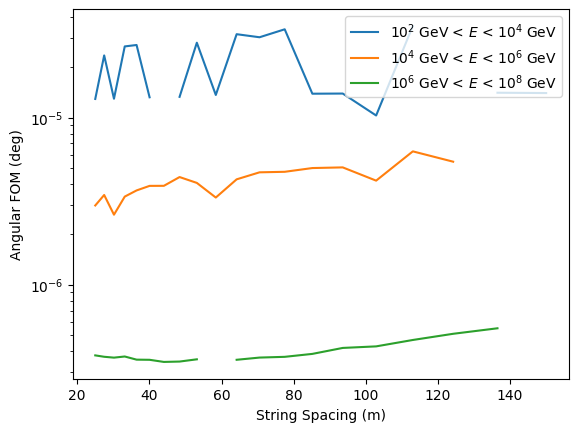

In [19]:
for energy in range(1, 4):    
    angular_foms = []
    for angular_loss_dict in angular_loss_dicts:
        squared_res = 0
        for i, params in enumerate(angular_loss_dict['resolution_params']):
            if params['energy'] >= 10**(2*energy) and params['energy'] < 10**(2*energy+2):
                squared_res += 1/angular_loss_dict['resolution_per_event'][i]**2  
        angular_foms.append(np.sqrt(squared_res))
    angular_foms = torch.stack(angular_foms).squeeze().cpu().numpy()
    plt.plot(np.logspace(np.log10(spacing_min), np.log10(spacing_max), spacing_count)[:len(angular_foms)], 1/angular_foms, label=fr"$10^{{{2*energy}}}$ GeV < $E$ < $10^{{{2*energy+2}}}$ GeV")
plt.xlabel("String Spacing (m)")
plt.ylabel("Angular FOM (deg)")
plt.yscale('log')
plt.legend()


In [37]:
1/angular_loss_dicts['6-8'][0]['angular_resolution_loss']

tensor(2839353.7500)

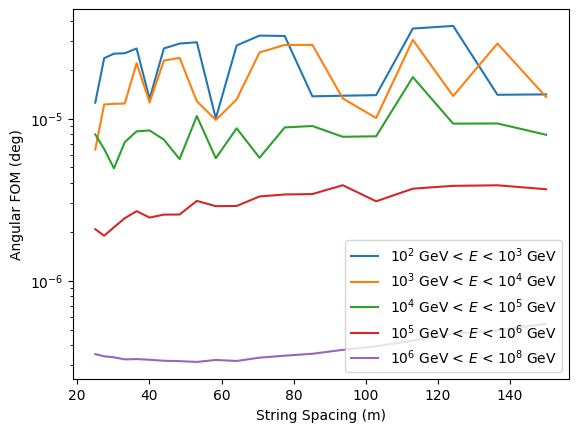

In [46]:
for energy in range(2,7):
    angular_foms = []
    for angular_loss_dict in angular_loss_dicts[f'{energy}-{energy+1}' if energy < 6 else f'{energy}-{energy+2}']:
        angular_foms.append(angular_loss_dict['angular_resolution_loss'])
    angular_foms = torch.stack(angular_foms).squeeze().cpu().numpy()
    plt.plot(np.logspace(np.log10(spacing_min), np.log10(spacing_max), spacing_count)[:len(angular_foms)], angular_foms, label=fr"10$^{{{energy}}}$ GeV < $E$ < $10^{{{energy+1 if energy < 6 else energy+2}}}$ GeV")
plt.xlabel("String Spacing (m)")
plt.ylabel("Angular FOM (deg)")
plt.yscale('log')
plt.legend()

In [50]:
# save angular_loss_dicts and energy_loss_dicts to a file
import pickle
# remove resolution_params in dicts to save space
copy_angular_loss_dicts = angular_loss_dicts.copy()
copy_energy_loss_dicts = energy_loss_dicts.copy()
for energy in range(2,7):
    for angular_loss_dict in copy_angular_loss_dicts[f'{energy}-{energy+1}' if energy < 6 else f'{energy}-{energy+2}']:
        del angular_loss_dict['resolution_params']
    for energy_loss_dict in copy_energy_loss_dicts[f'{energy}-{energy+1}' if energy < 6 else f'{energy}-{energy+2}']:
        del energy_loss_dict['resolution_params']
with open('pois_angular_loss_dicts_energies.pkl', 'wb') as f:
    pickle.dump(copy_angular_loss_dicts, f)

with open('pois_energy_loss_dicts_energies.pkl', 'wb') as f:
    pickle.dump(copy_energy_loss_dicts, f)

In [38]:
angular_foms

array([1.8436865e+06, 1.8436865e+06, 1.8436865e+06, 1.8436865e+06,
       1.8436865e+06, 1.8436865e+06, 1.8436865e+06, 1.8436865e+06,
       1.8436865e+06, 1.8436865e+06, 1.8436865e+06, 1.8436865e+06,
       1.8436865e+06, 1.8436865e+06, 1.8436865e+06, 1.8436865e+06,
       1.8436865e+06, 1.8436865e+06, 1.8436865e+06, 1.8436865e+06],
      dtype=float32)

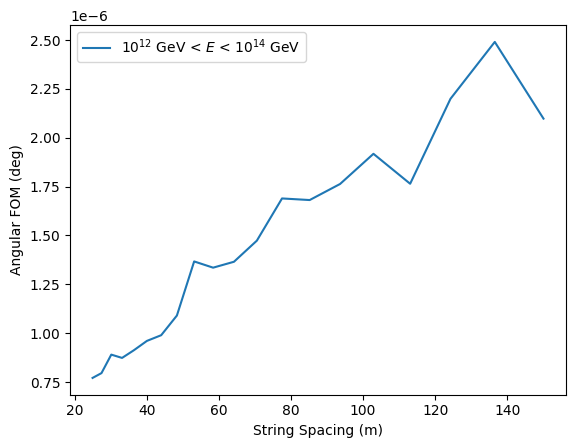

In [17]:
double_e = 2*energy
plt.plot(np.logspace(np.log10(spacing_min), np.log10(spacing_max), spacing_count)[:len(angular_foms)], 1/angular_foms, label=fr"10$^{{{double_e}}}$ GeV < $E$ < $10^{{{double_e+2}}}$ GeV")
plt.xlabel("String Spacing (m)")
plt.ylabel("Angular FOM (deg)")
plt.legend()

Text(0, 0.5, 'Median Energy Resolution (GeV)')

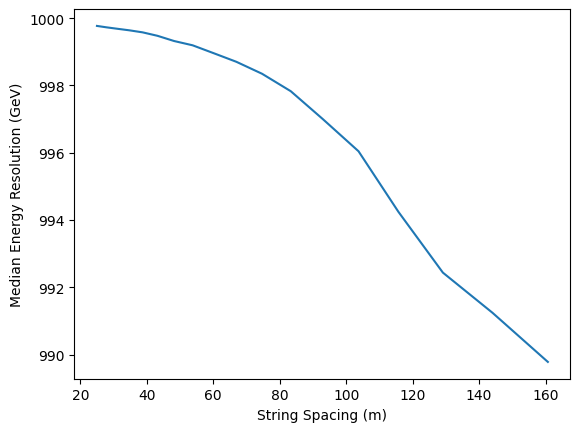

In [29]:
mean_energies = torch.stack(mean_energies).squeeze().cpu().numpy()
plt.plot(np.logspace(np.log10(spacing_min), np.log10(spacing_max), spacing_count)[:len(mean_energies)], mean_energies)
plt.xlabel("String Spacing (m)")
plt.ylabel("Median Energy Resolution (GeV)")